## Churn Analysis and Customer Intelligence

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import pyodbc
import warnings
warnings.filterwarnings("ignore")

## 1. Import database / data

In [3]:
conn = pyodbc.connect('Driver={SQL Server};'
                      'Server=localhost\SQLEXPRESS;'
                      'database=customer_churn;'
                      'Trusted_Connection=yes;')



query=""" select table_schema, table_name from 
                                information_schema.tables 
                                where table_type = 'base table'        """
tables = pd.read_sql(query,conn)


for table in tables["table_name"]:
    query = f"SELECT * FROM [{table}]"

    globals()[f"df_{table}"] = pd.read_sql(query, conn)
    print(f"created Dataframe: df_{table}")
    
conn.close()

created Dataframe: df_db_subscription
created Dataframe: df_db_customer
created Dataframe: df_db_support


C:\Users\hp\AppData\Local\Temp\ipykernel_20124\3154887391.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query,conn)
C:\Users\hp\AppData\Local\Temp\ipykernel_20124\3154887391.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  globals()[f"df_{table}"] = pd.read_sql(query, conn)


## Data Cleaning

In [4]:
print(df_db_customer.head())
print(df_db_customer.tail())

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06,None,None


In [17]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [18]:
# a. rename - name
# b. drop column- intersts,pincode
# c. change datatype- dob
# d. data standardization- gander
# e. fix missing value- country

#### a. Rename Col

In [5]:
df_db_customer.rename(columns={"name" : "Customer_name"},inplace=True)
df_db_customer

,customerid,Customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29,None,None


#### b. Drop columns

In [6]:
# b. drop columns - interest and pincode

df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
df_db_customer.drop(columns=['interests','pincode'],axis=1,inplace=True)

#### c. Change data type

In [7]:
# c. change datatype- dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

#### d. Data standardization

In [8]:
# d. data standardization- gander

df_db_customer['gender'].replace({'Men' : "Male",'Women' : "Female"},inplace=True)
df_db_customer['gender'].unique()

C:\Users\hp\AppData\Local\Temp\ipykernel_20124\794813790.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men' : "Male",'Women' : "Female"},inplace=True)


#### e. Fix missing values

In [ ]:
# e. fix missing values - country

df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

In [9]:
# country and state - unique value pair
state_country_maping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_maping))

In [136]:
df_db_subscription.head() # subscription Table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [76]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [10]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date

date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [78]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,45597,False,30,None,None
5,0017-IUDMW,45392,True,25,None,None
6,0019-EFAEP,45562,True,30,None,None
7,0022-TCJCI,45548,True,10,None,None
8,0022-TCJCI,45549,False,90,None,received refund


In [79]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      int64 
 2   escalations     9 non-null      bool  
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 501.0+ bytes


In [11]:
# drop columns
df_db_support.drop(columns=df_db_support.columns[-2:],axis=1,inplace=True)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [12]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

## 3. Feature Engineering & Data Analysis

#### Create a new col

In [13]:
df_db_subscription.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91


In [13]:
# create a new col using existing col - churn flag

df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(), 1,0)
df_db_subscription.head()

### Merge Dataframes - JOINs

In [12]:
df = (df_db_subscription
                    .merge(df_db_customer, on='customerid', how= 'left')
                    .merge(df_db_support, on='customerid', how= 'left'))

In [ ]:
df_db_subscription.shape

In [15]:
df.shape

In [ ]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

In [ ]:
df_db_support

In [ ]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [ ]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [ ]:
df_db_support['customerid'].size

In [ ]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [ ]:
df.shape

### Data Analysis

In [2]:
# 1. churn Rate
churn_rate = df['churn_flag'].mean()*100
print("churn_rate =",round(churn_rate,2),"%")

In [20]:
# 2. Retention Rate
retention_rate = 100-churn_rate
print('Retention Rate =',round(retention_rate,2),"%")

Retention Rate = 71.43 %


In [21]:
# 3. Churn by Plan Type
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
churn_by_plan

In [47]:
# 4 a churn by state + sum(revenue)&count_of_users  --home work **
# 4 b churn by subcription type + sum(revenue)&count_of_users

In [23]:
# 5. ARPU - Avg Revenue per user
ARPU = df['monthly_charges'].mean()
print('ARPU =',round(ARPU,2))

ARPU = 18.85 %


In [24]:
# 6. Avg Customer Tenure

today=pd.Timestamp.today()

df['tenure_days']= np.where(
    df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean() 
print("Avg_tenure = ",round(avg_tenure,2),"%")

Avg_tenure =  1542.29 %


In [25]:
# 7. Revenue at risk - revenue lost from churned users

Revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print('Revenue at risk (Rs)=',round(Revenue_at_risk,2),"k")

Revenue at risk (Rs)= 73.94 k


In [27]:
# 8. Escalation Rate

Escalation_rate = (df['escalations']=='Y').mean()*100
print('Escalation Rate =',round(Escalation_rate,2))

Escalation Rate = 19.05


In [28]:
# 9. Avg Complaint Per User

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print('Avg complaint per user =',round(avg_complaints,2),'%')

Avg complaint per user = 0.43 %


In [30]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations']=='Y', 1, 0) # encoding str to int type
corr_df = df[['escalations','churn_flag']].dropna()

correalation = corr_df['escalations'].corr(df['churn_flag'])
print('Correlation between escalations vs churn is =',round(correalation,2))

Correlation between escalations vs churn is = 0.77


In [31]:
# 11. Create a column using existing col - Churn risk
conditions = [
    (df['churn_score']<=50),
    (df['churn_score']>50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
score=['Low',"Mid",'High']

df['churn_risk'] = np.select(conditions,score,default='unknown')

## 4. Visualization using Matplotlib

In [36]:
df_visual=df.copy()

(21, 23)

In [37]:
df_visual.keys()

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

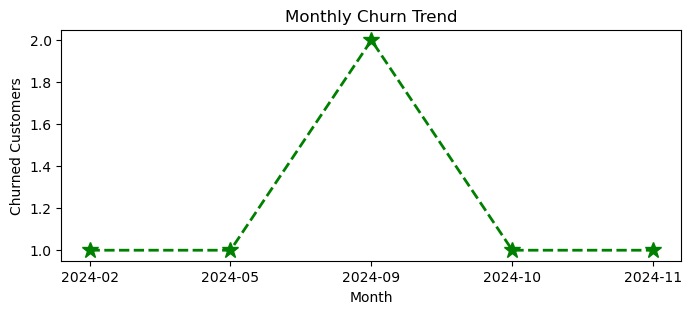

In [48]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='*', linestyle='dashed',linewidth=2, markersize=12)
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

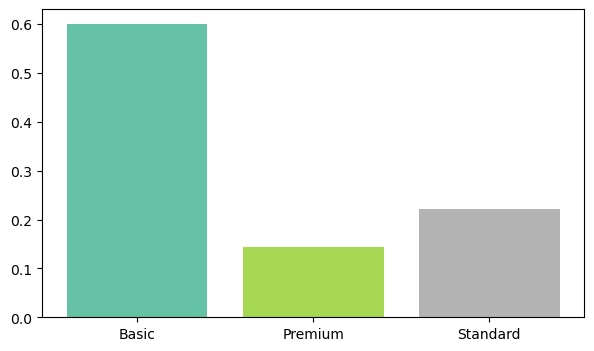

In [69]:
# 4.2 Churn Rate by Plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
    
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

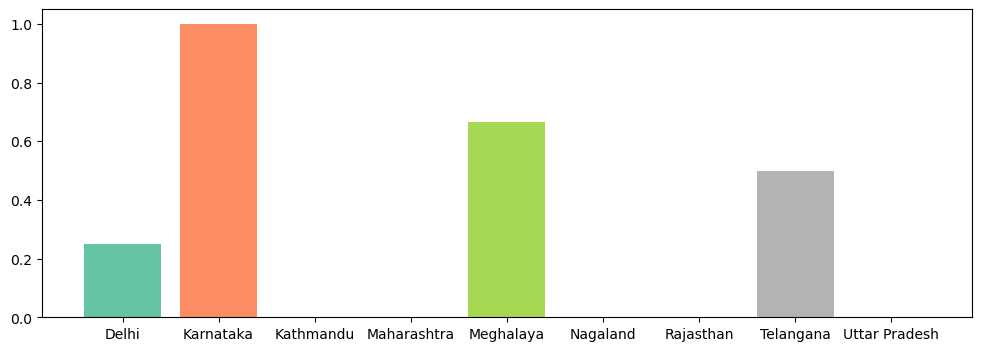

In [74]:
# 4.3 Churn by States

churn_state = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_state)))

plt.figure(figsize=(12,4))
plt.bar(churn_state.index,churn_state.values,color=colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## Visulaization using Seaborn

In [ ]:
# Heatmap (Correlation Matrix)

In [89]:
# Incoding - based on priority
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','escalations','churn_risk']]

order_mappings ={'plan_type' : ['Basic','Standard','Premium'],
                'contract_type' : ['Monthly','Annual'],
                'churn_risk' : ['Low','Mid','High']
               }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype("category"),categories=order, ordered=True).codes
    

In [ ]:
df_encoded

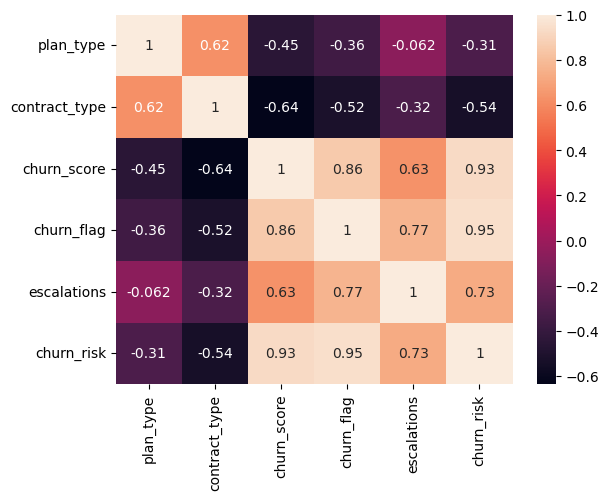

In [92]:
# Heatmap - correlation matrix
sn.heatmap(df_encoded.corr(), annot=True)
plt.title("Heatmap")
plt.show()

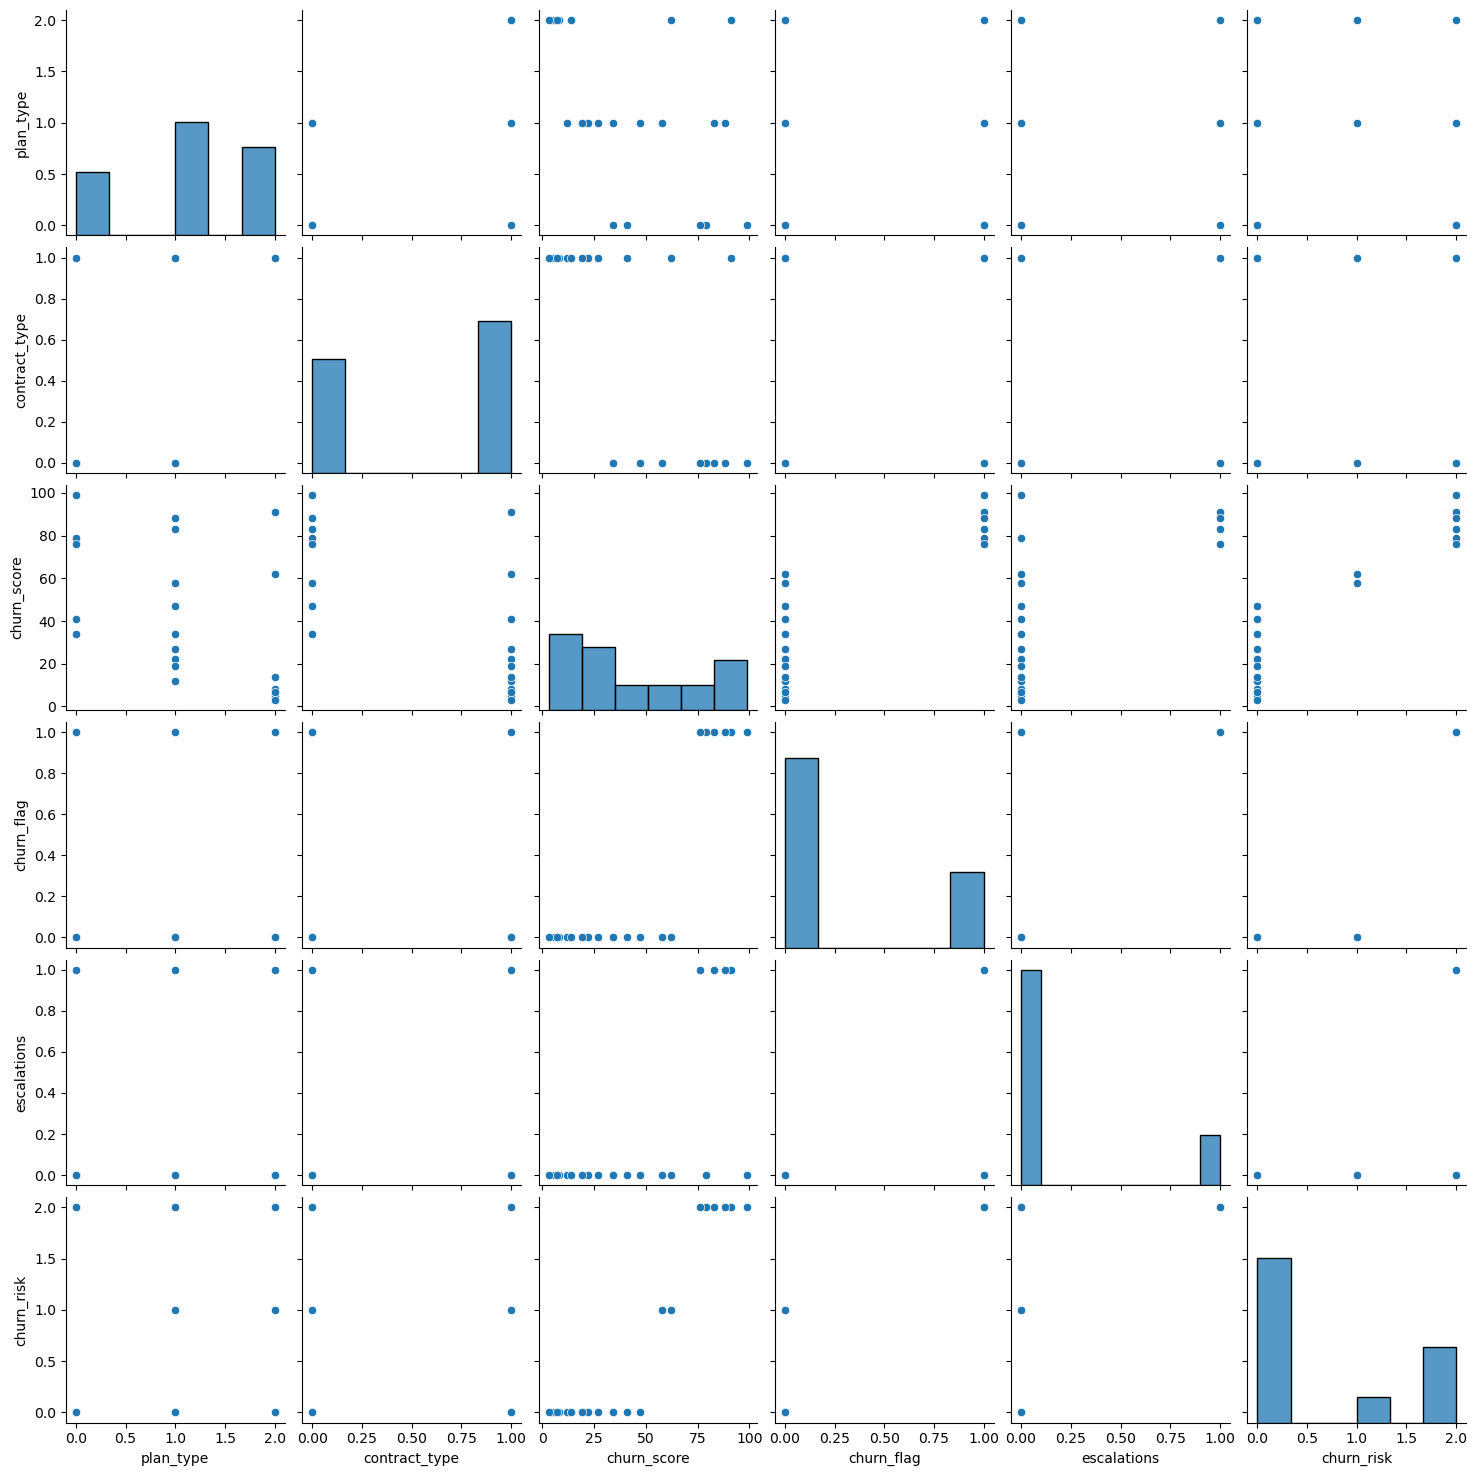

In [93]:
# pairplot - Plot pairwise relationships in a dataset
sn.pairplot(df_encoded)
plt.show()

In [ ]:
df_visual.columns

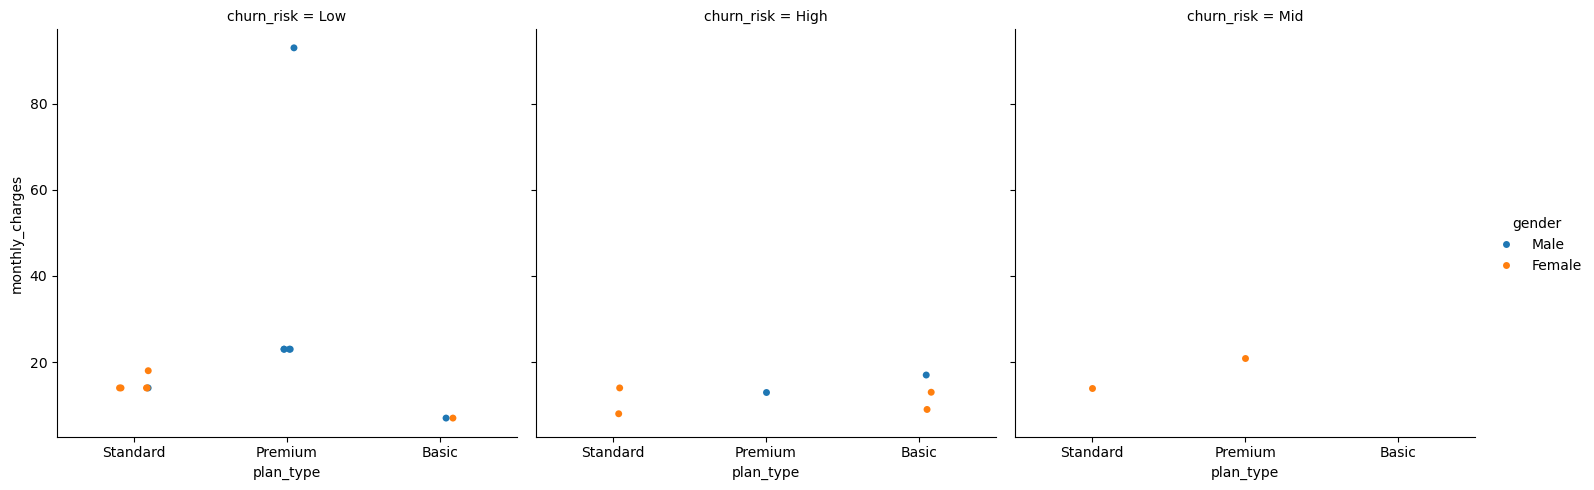

In [98]:
# catplt/Facegrid plot - multi-dim comparison

sn.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')
plt.show()

### Pivot Table


In [ ]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)